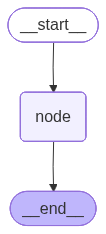

In [12]:
from langchain_core.messages import AnyMessage,AIMessage
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from IPython.display import Image,display

# 定义节点间通讯的消息格式
class State(TypedDict):
    messages:list[AnyMessage]
    extra_field:int

# 定义节点(一般是一个函数)
def node(state:State):
    messages = state["messages"]
    new_message = AIMessage("你好！我是节点1")



    return {
        "messages": messages + [new_message],
        "extra_field":1
    }

#创建图
"""
包含一个节点
使用state通信
"""
graph = StateGraph(State)
graph.add_node("node",node)
graph.set_entry_point("node")
graph_builder = graph.compile()

#查看节点与图结构
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#### 调用

In [13]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好呀！我是starry")]
})
result

{'messages': [HumanMessage(content='你好呀！我是starry', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！我是节点1', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'extra_field': 1}

##### 使用pretty_print来格式化显示

In [14]:
from langchain_core.messages import HumanMessage

result = graph_builder.invoke({
    "messages":[HumanMessage("你好呀！我是starry")]
})
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

你好呀！我是starry
================================== Ai Message ==================================

你好！我是节点1



## 串行控制


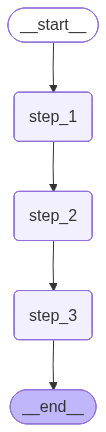

In [19]:
from typing_extensions import TypedDict
from IPython.display import Image,display
from langgraph.graph import START,StateGraph,END

class State(TypedDict):
    value_1:str
    value_2:str

def step_1(state:State):
    return {"value_1":"a"}

def step_2(state:State):
    current_value_1 = state["value_1"]
    return {"value_1":f"{current_value_1}+b"}

def step_3(state:State):
    return {"value_2":10}

graph_builder = StateGraph(State)
graph_builder.add_node(step_1)#节点
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

graph_builder.add_edge(START,"step_1")#边
graph_builder.add_edge("step_1","step_2")
graph_builder.add_edge("step_2","step_3")
graph_builder.add_edge("step_3",END)


graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
graph.invoke({"value_1":"c"})

{'value_1': 'a+b', 'value_2': 10}

## 分支控制

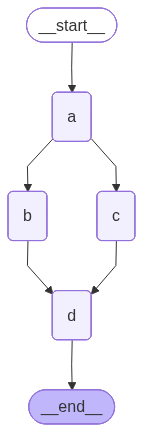

In [23]:
import operator
from typing import Any,Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加'A'到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加'B'到{state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"添加'C'到{state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"添加'D'到{state['aggregate']}")
    return {"aggregate":["D"]}


builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

builder.add_edge(START,"a")
builder.add_edge("a","b")
builder.add_edge("a","c")
builder.add_edge("b","d")
builder.add_edge("c","d")
builder.add_edge("d",END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
graph.invoke({"aggregate":[]},{"configurable":{"thread_id":"foo"}})

添加'A'到[]
添加'B'到['A']
添加'C'到['A']
添加'D'到['A', 'B', 'C']


{'aggregate': ['A', 'B', 'C', 'D']}

## 条件分支和循环

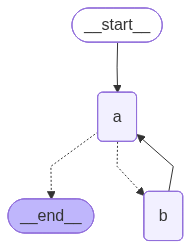

In [26]:
import operator
from typing import Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加'A'到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加'B'到{state['aggregate']}")
    return {"aggregate":["B"]}

builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)

#定义 边
def route(state: State) -> Literal["b", END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END


builder.add_edge(START,"a")
builder.add_conditional_edges("a", route) #条件边
builder.add_edge("b","a")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
graph.invoke({"aggregate": []})

添加'A'到[]
添加'B'到['A']
添加'A'到['A', 'B']
添加'B'到['A', 'B', 'A']
添加'A'到['A', 'B', 'A', 'B']
添加'B'到['A', 'B', 'A', 'B', 'A']
添加'A'到['A', 'B', 'A', 'B', 'A', 'B']


{'aggregate': ['A', 'B', 'A', 'B', 'A', 'B', 'A']}

使用递归限制recursion_limit来防止异常情况下的大量无用调用

In [28]:
from langgraph.errors import GraphRecursionError

try:
    graph.invoke({"aggregate": []},{"recursion_limit": 4})
except GraphRecursionError:
    print("Reursion Error")

添加'A'到[]
添加'B'到['A']
添加'A'到['A', 'B']
添加'B'到['A', 'B', 'A']
Reursion Error


## 循环

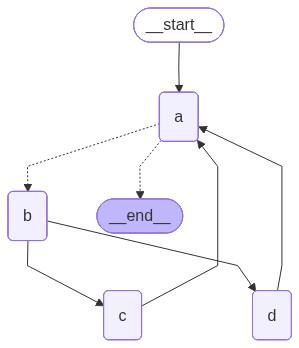

In [30]:
import operator
from typing import Any,Annotated,Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

class State(TypedDict):
    aggregate:Annotated[list,operator.add]

def a(state:State):
    print(f"添加'A'到{state['aggregate']}")
    return {"aggregate":["A"]}

def b(state:State):
    print(f"添加'B'到{state['aggregate']}")
    return {"aggregate":["B"]}

def c(state:State):
    print(f"添加'C'到{state['aggregate']}")
    return {"aggregate":["C"]}

def d(state:State):
    print(f"添加'D'到{state['aggregate']}")
    return {"aggregate":["D"]}


builder = StateGraph(State)
builder.add_node(a)
builder.add_node(b)
builder.add_node(c)
builder.add_node(d)

#边
def route(state:State)->Literal["b",END]:
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END

builder.add_edge(START,"a")
builder.add_conditional_edges("a",route)
builder.add_edge("b","c")
builder.add_edge("b","d")
builder.add_edge(["c","d"], "a")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
result = graph.invoke({"aggregate":[]})

添加'A'到[]
添加'B'到['A']
添加'C'到['A', 'B']
添加'D'到['A', 'B']
添加'A'到['A', 'B', 'C', 'D']
添加'B'到['A', 'B', 'C', 'D', 'A']
添加'C'到['A', 'B', 'C', 'D', 'A', 'B']
添加'D'到['A', 'B', 'C', 'D', 'A', 'B']
添加'A'到['A', 'B', 'C', 'D', 'A', 'B', 'C', 'D']


## 图的运行时配置

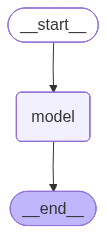

In [2]:
import operator
from typing import Annotated,Sequence
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
from dotenv import load_dotenv
load_dotenv()

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    temperature = 0,
    api_key = os.environ.get("DEEPSEEK_API_KEY"),
    base_url = os.environ.get("DEEPSEEK_API_BASE"),
)

model1 = ChatOpenAI(
    model = "gpt-3.5-turbo",
    temperature = 0,
    api_key = os.environ.get("OPENAI_API_KEY"),
    base_url = os.environ.get("OPENAI_API_BASE"),
)

models = {
    "deepseek": model,
    "openai": model1,
}

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

def _call_model(state: AgentState, config: RunnableConfig):
    #使用LCEL的配置
    model_name = config["configurable"].get("model", "deepseek")
    model = models[model_name]
    response = model.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(AgentState)
builder.add_node("model", _call_model)
builder.add_edge(START, "model")
builder.add_edge("model", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [3]:
graph.invoke({"messages": [HumanMessage(content = "hi 你是谁？")]})

{'messages': [HumanMessage(content='hi 你是谁？', additional_kwargs={}, response_metadata={}),
  AIMessage(content='你好！我是DeepSeek，由深度求索公司创造的AI助手。很高兴认识你！😊\n\n我是纯文本模型，支持处理各种文字问题，还能阅读链接、上传文件（图片、PDF、Word、Excel等），帮你分析内容。我有1M的超长上下文，可以一次性处理像《三体》三部曲那么厚的书籍！\n\n最重要的是，我完全免费使用，没有任何收费计划。如果你想联网搜索，记得在Web或App上手动点开联网搜索按钮哦。\n\n有什么我可以帮你的吗？无论是解答问题、写作、编程还是其他需求，尽管问我！💪', additional_kwargs={'refusal': None, 'reasoning_content': '好的，用户问“hi 你是谁？”，这是一个非常简单的自我介绍问题。用户可能是初次接触，想了解我的身份和基本功能。\n\n我需要直接、清晰地说明我是谁，我的创造者，以及我的核心能力。可以用友好的语气开头，然后列出关键特点，比如免费、长上下文、文件处理等，最后以提供帮助的邀请结束。\n\n想到了用“你好！我是DeepSeek”来直接回应，然后简要介绍公司和版本，接着用几个要点概括主要功能。这样既回答了问题，也方便用户知道我能做什么。'}, response_metadata={'token_usage': {'completion_tokens': 241, 'prompt_tokens': 8, 'total_tokens': 249, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 114, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens

#### 增加运行时配置，动态切换模型

In [4]:
config = {"configurable": {"model": "openai"}}
graph.invoke({"messages":[HumanMessage(content="hi 你是谁？")]}, config = config)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: your_ope************here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

## MapReduce并行执行

In [ ]:
import operator
from typing import Annotated,Sequence
from typing_extensions import TypedDict

from langchain_deepseek import ChatDeepSeek
from langchain_openai import ChatOpenAI
import os
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.runnables.config import RunnableConfig
from langgraph.graph import StateGraph,START,END

from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()

from langgraph.types import Send


#模型和提示词
#定义我们将使用的模型和提示词
subjects_prompt = """
主题：{topic}

请返回5个具体实例。

例如：

主题：水果
["苹果","香蕉","葡萄","西瓜","橙子"]

主题：动物
"""
joke_prompt = """生成一个关于{subject}的笑话"""
best_joke_prompt = """以下是一些关于{topic}的笑话，选出最好的一个！返回最佳笑话的ID。

{jokes}"""

class Subjects(BaseModel):
    subjects: list[str]

class Joke(BaseModel):
    joke: str

class BestJoke(BaseModel):
    id: int = Field(description="最佳笑话的索引，从0开始", ge = 0)

model = ChatDeepSeek(
    model = "deepseek-chat",
    temperature = 0,
    api_key = os.environ.get("DEEPSEEK_API_KEY"),
    base_url = os.environ.get("DEEPSEEK_API_BASE"),
)
 
# 这将是主题的整体状态。
# 它将包含一个主题（我们期望用户提供）
# 然后将生成一个主题列表，并为每个主题生成一个笑话

class OverallState(TypedDict):
    topic: str
    subjects: list
    
    # 注意这里我们使用Operator.add
    # 这是因为我们想把从各个节点生成的所有笑话
    # 合并回一个列表 - 这本质上是“归约”部分
    jokes: Annotated[list, operator.add]
    
    best_selected_joke: str

# 用于生成笑话
class  JokeState(TypedDict):
    subject: str
    jokes: Annotated[list, operator.add]

# 这是我们用来生成笑话主题的函数
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = model.with_structured_output(Subjects).invoke(prompt)
    print("subjects =", response.subjects)

    return {"subjects": response.subjects}

# 这是我们根据给定的主题生成笑话
def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = model.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

# 这里我们定义映射到生成的主题上的逻辑
# 我们将在图中使用这个作为边缘

def continue_to_jokes(state: OverallState):
    # 我们将返回一个 Send 对象列表
    # 每个 Send 对象包含图中节点的名称
    # 以及要发送到该节点的状态
    return [Send('generate_joke', {'subject': s}) for s in state['subjects']]

# 这里我们将评判最佳笑话
def best_joke(state: OverallState):
    jokes = "\n".join(
        [f"{i}: {j}" for i, j in enumerate(state["jokes"])]
    )
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

# 构建图：这里我们将所有内容组合在一起构建我们的图
graph = StateGraph(OverallState)

# 添加节点：定义图中的各个处理单元
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)

# 添加边：定义节点之间的流转逻辑
graph.add_edge(START, "generate_topics")  # 从起始节点指向主题生成
# 条件边：根据 generate_topics 的结果，动态路由到多个 generate_joke 节点
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")  # 从笑话生成指向最佳笑话评选
graph.add_edge("best_joke", END)             # 从最佳笑话指向结束节点

# 编译图：将定义好的图结构编译为可执行的应用
app = graph.compile()

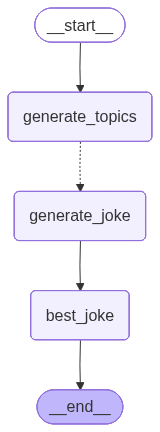

In [20]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [21]:
for s in app.stream({"topic": "动物"}):
    print(s)

subjects = ['动物']
{'generate_topics': {'subjects': ['动物']}}
{'generate_joke': {'jokes': ['为什么企鹅的肚子是白色的？因为如果它的肚子也是黑色的，它摔倒的时候你就找不到它了！']}}
{'best_joke': {'best_selected_joke': '为什么企鹅的肚子是白色的？因为如果它的肚子也是黑色的，它摔倒的时候你就找不到它了！'}}
